In [3]:
import numpy as np
import torch
import torch.fft
import matplotlib.pyplot as plt
from PIL import Image


In [25]:

# 加载本地图像 test.png
image = Image.open("test.png").convert('L')  # 转为灰度图
image = np.array(image).astype(np.float32)  # 转换为浮点类型
image = torch.tensor(image)

# 进行傅立叶变换
fft_image = torch.fft.rfft2(image)

# 获取幅度和相位
amplitude = torch.abs(fft_image)
phase = torch.angle(fft_image)

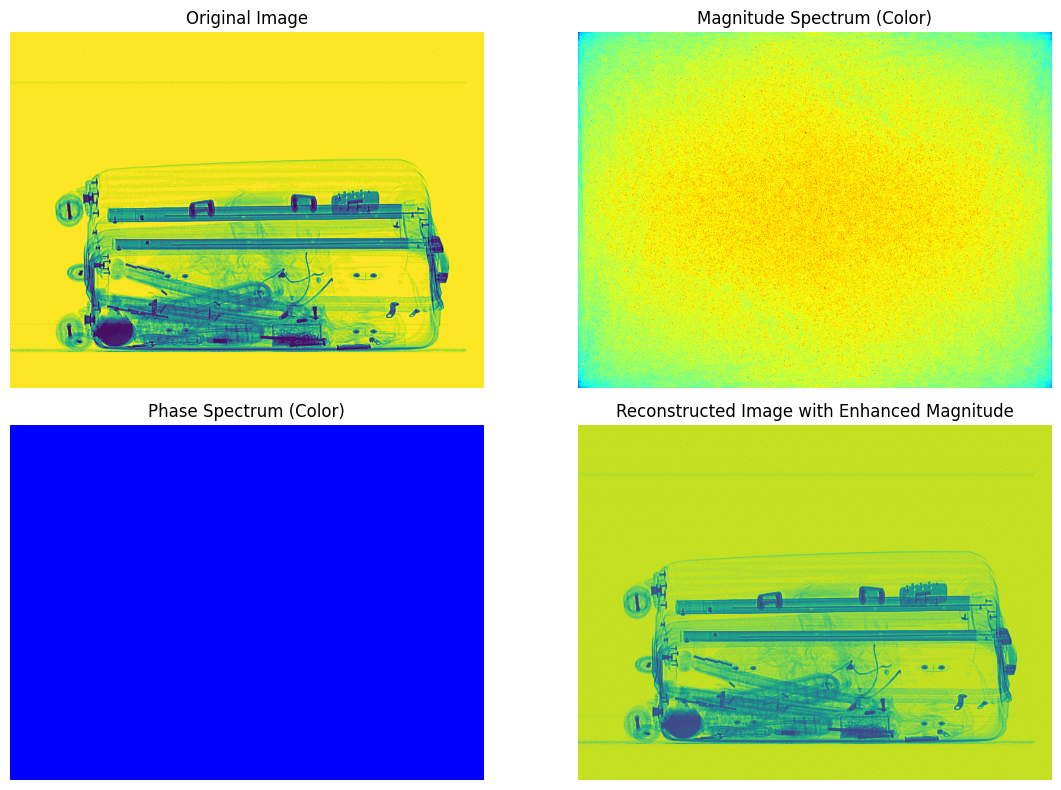

In [35]:
import numpy as np
import torch
import torch.fft
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# Load the image 'test.png'
image = Image.open("test.png").convert('L')  # Convert to grayscale
image = np.array(image).astype(np.float32)  # Convert to float type
image = torch.tensor(image)

# Perform Fourier transform
fft_image = torch.fft.fft2(image)

# Get magnitude and phase
amplitude = torch.abs(fft_image)
phase = torch.angle(fft_image)

# Enhance the magnitude (e.g., boost high frequencies)
enhanced_amplitude = amplitude * (1 + 100 * (amplitude > amplitude.mean()))

# Reconstruct the image using enhanced magnitude and original phase
enhanced_fft = enhanced_amplitude * torch.exp(1j * phase)
reconstructed_image = torch.fft.ifft2(enhanced_fft).real

# Convert the magnitude and phase to color images
def amplitude_to_color(amplitude):
    # Apply logarithmic transformation and normalize to [0, 255]
    log_amplitude = np.log1p(amplitude)  # Log transform
    log_amplitude = cv2.normalize(log_amplitude, None, 0, 255, cv2.NORM_MINMAX)
    # Convert to color using a colormap
    color_amplitude = cv2.applyColorMap(log_amplitude.astype(np.uint8), cv2.COLORMAP_JET)
    return color_amplitude

def phase_to_color(phase):
    # Map phase to [0, 255] range, then to HSV color
    phase = np.angle(phase)
    phase = np.unwrap(phase)  # Unwrap phase to avoid jumps
    phase = np.interp(phase, (phase.min(), phase.max()), (0, 255))  # Map to 0-255
    phase_color = cv2.applyColorMap(phase.astype(np.uint8), cv2.COLORMAP_HSV)  # Use HSV colormap
    return phase_color

# Visualize the original image, magnitude spectrum, phase spectrum, and reconstructed image
plt.figure(figsize=(12, 8))

# Display the original image
plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(image.numpy())
plt.axis('off')

# Display the magnitude spectrum (color)
plt.subplot(2, 2, 2)
plt.title("Magnitude Spectrum (Color)")
color_amplitude = amplitude_to_color(amplitude.numpy())  # Convert to color
plt.imshow(color_amplitude)
plt.axis('off')

# Display the phase spectrum (color)
plt.subplot(2, 2, 3)
plt.title("Phase Spectrum (Color)")
color_phase = phase_to_color(enhanced_amplitude.numpy())  # Convert to color
plt.imshow(color_phase)
plt.axis('off')

# Display the reconstructed image with enhanced magnitude
plt.subplot(2, 2, 4)
plt.title("Reconstructed Image with Enhanced Magnitude")
plt.imshow(reconstructed_image.numpy())
plt.axis('off')

plt.tight_layout()
plt.show()
